# IBM Stock EDA

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
sys.path.append(os.path.abspath('..'))
from src.utils import count_outliers_iqr,check_negative_prices,check_ohlc_validity,calculate_volatility,calculate_bullish_bearish

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

## Load the data

In [3]:
df = pd.read_csv("../data/raw/ibm_stock_1980_2025.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Adj Factor
0,1980-01-02,15.057361,15.415870,14.937859,14.937859,0.965845,"1,723,808",0.0,0.0,0.064657
1,1980-01-03,14.937859,15.176864,14.639101,15.176864,0.981298,"2,553,495",0.0,0.0,0.064657
2,1980-01-04,15.176864,15.236616,15.057361,15.146989,0.979366,"1,978,195",0.0,0.0,0.064657
3,1980-01-07,15.146989,15.146989,14.967734,15.087237,0.975503,"1,480,718",0.0,0.0,0.064657
4,1980-01-08,15.087237,16.132887,14.967734,16.103010,1.041180,"2,968,130",0.0,0.0,0.064657


In [4]:
df.shape

(11488, 10)

## Basic info and data checks

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11488 entries, 0 to 11487
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          11488 non-null  str    
 1   Open          11488 non-null  float64
 2   High          11488 non-null  float64
 3   Low           11488 non-null  float64
 4   Close         11488 non-null  float64
 5   Adj Close     11488 non-null  float64
 6   Volume        11488 non-null  str    
 7   Dividends     11488 non-null  float64
 8   Stock Splits  11488 non-null  float64
 9   Adj Factor    11488 non-null  float64
dtypes: float64(8), str(2)
memory usage: 1.1 MB


In [6]:
df.dtypes

Date                str
Open            float64
High            float64
Low             float64
Close           float64
Adj Close       float64
Volume              str
Dividends       float64
Stock Splits    float64
Adj Factor      float64
dtype: object

In [7]:
df['Volume'] = df['Volume'].apply(lambda x: float(x.replace(',','')))

In [8]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Adj Factor
count,11488.000000,11488.000000,11488.000000,11488.000000,11488.000000,1.148800e+04,11488.000000,11488.000000,11488.000000
mean,86.395437,87.205402,85.627898,86.434003,50.850399,6.686743e+06,0.009136,0.000440,0.411739
std,59.715942,60.191946,59.273661,59.765258,52.400382,4.435882e+06,0.100572,0.028146,0.284595
min,9.799235,9.978489,9.709608,9.799235,0.800124,0.000000e+00,0.000000,0.000000,0.064657
25%,27.605164,27.844168,27.336281,27.605164,2.569202,3.918679e+06,0.000000,0.000000,0.104355
50%,84.574570,85.468452,83.742832,84.694077,42.765790,5.603892e+06,0.000000,0.000000,0.504918
75%,132.660133,133.749996,131.791824,132.796360,93.500592,8.137932e+06,0.000000,0.000000,0.597871
max,294.549988,296.160004,290.359985,294.779999,294.779999,7.263916e+07,1.680000,2.000000,1.000000


In [9]:
# is there Date duplicate rows?
df['Date'].duplicated().sum()

np.int64(0)

In [10]:
df[df['Volume'] == 0]

,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Adj Factor
510,1982-01-08,13.563576,13.563576,13.563576,13.563576,0.983842,0.0,0.0,0.0,0.072536


## Fix date column

In [11]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df["Date"].min(), df["Date"].max()

(Timestamp('1980-01-02 00:00:00'), Timestamp('2025-07-30 00:00:00'))

## Missing values

In [12]:
df.isnull().sum()

Date            0
Open            0
High            0
Low             0
Close           0
Adj Close       0
Volume          0
Dividends       0
Stock Splits    0
Adj Factor      0
dtype: int64

In [13]:
invalid_rows = check_ohlc_validity(df)
invalid_rows

invalid OHLC rows: 0


0        False
1        False
2        False
3        False
4        False
         ...  
11483    False
11484    False
11485    False
11486    False
11487    False
Length: 11488, dtype: bool

In [14]:
negative_rows = check_negative_prices(df)
negative_rows

negative or zero price rows: 0


0        False
1        False
2        False
3        False
4        False
         ...  
11483    False
11484    False
11485    False
11486    False
11487    False
Length: 11488, dtype: bool

In [15]:
calculate_bullish_bearish(df)

candle_type
bullish    5655
bearish    5535
neutral     298
Name: count, dtype: int64


,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Adj Factor,candle_type
0,1980-01-02,15.057361,15.415870,14.937859,14.937859,0.965845,1723808.0,0.0,0.0,0.064657,bearish
1,1980-01-03,14.937859,15.176864,14.639101,15.176864,0.981298,2553495.0,0.0,0.0,0.064657,bullish
2,1980-01-04,15.176864,15.236616,15.057361,15.146989,0.979366,1978195.0,0.0,0.0,0.064657,bearish
3,1980-01-07,15.146989,15.146989,14.967734,15.087237,0.975503,1480718.0,0.0,0.0,0.064657,bearish
4,1980-01-08,15.087237,16.132887,14.967734,16.103010,1.041180,2968130.0,0.0,0.0,0.064657,bullish
...,...,...,...,...,...,...,...,...,...,...,...
11483,2025-07-24,261.250000,262.049988,252.750000,260.510010,260.510010,22647700.0,0.0,0.0,1.000000,bearish
11484,2025-07-25,260.019989,260.799988,256.350006,259.720001,259.720001,7758700.0,0.0,0.0,1.000000,bearish
11485,2025-07-28,260.299988,264.000000,259.609985,263.209991,263.209991,5192500.0,0.0,0.0,1.000000,bullish
11486,2025-07-29,264.299988,265.799988,261.019989,262.410004,262.410004,4627300.0,0.0,0.0,1.000000,bearish


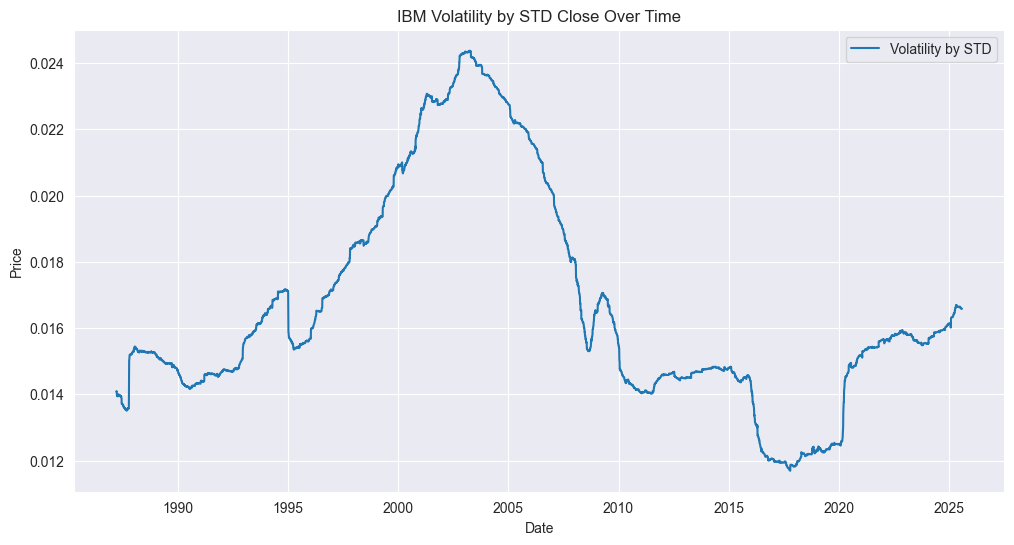

In [19]:
volatility_df = calculate_volatility(df,1826)
plt.plot(volatility_df["Date"], volatility_df["volatility"], label="Volatility by STD")
plt.legend()
plt.title("IBM Volatility by STD Close Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

## Date continuity check
See if there are gaps in the trading days (weekends and holidays are expected, but big gaps are worth checking).

In [39]:
df["days_gap"] = df["Date"].diff().dt.days
df["days_gap"].value_counts().sort_index(ascending=False).head(10)

days_gap
7.0       1
5.0       2
4.0     287
3.0    2088
2.0     108
1.0    9001
Name: count, dtype: int64

In [46]:
# rows where the gap between trading days is unusually big
df[df["days_gap"] == 7]

,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Adj Factor,days_gap
5482,2001-09-17,89.770554,91.644356,88.479927,89.235184,44.762874,"15,828,909",0.0,0.0,0.501628,7.0


## Ranges over time

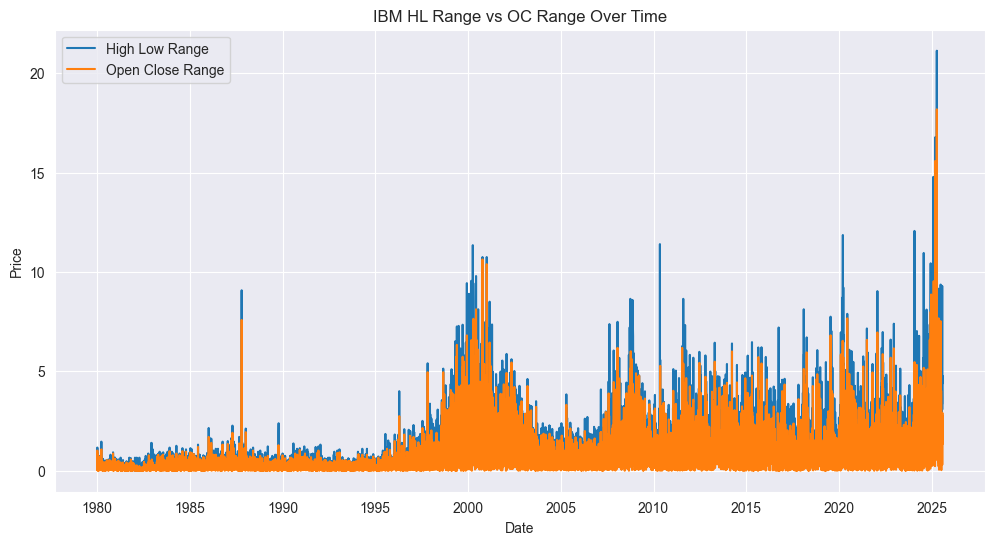

In [39]:
df["high_low_range"] = df["High"] - df["Low"]
df["open_close_range"] = (df["Close"] - df["Open"]).abs()

plt.plot(df["Date"], df["high_low_range"], label="High Low Range")
plt.plot(df["Date"], df["open_close_range"], label="Open Close Range")
plt.legend()
plt.title("IBM HL Range vs OC Range Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

## Price trends over time

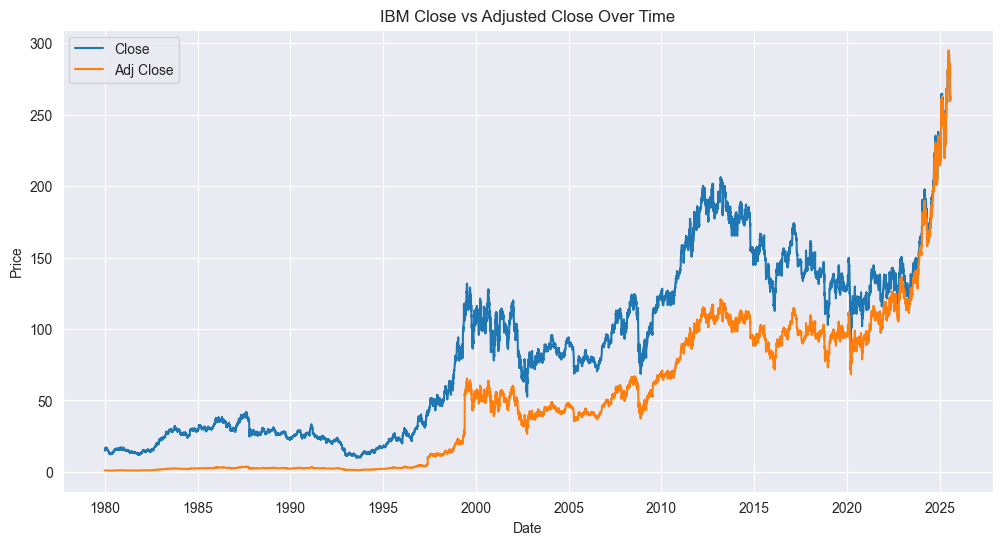

In [47]:
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["Adj Close"], label="Adj Close")
plt.legend()
plt.title("IBM Close vs Adjusted Close Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

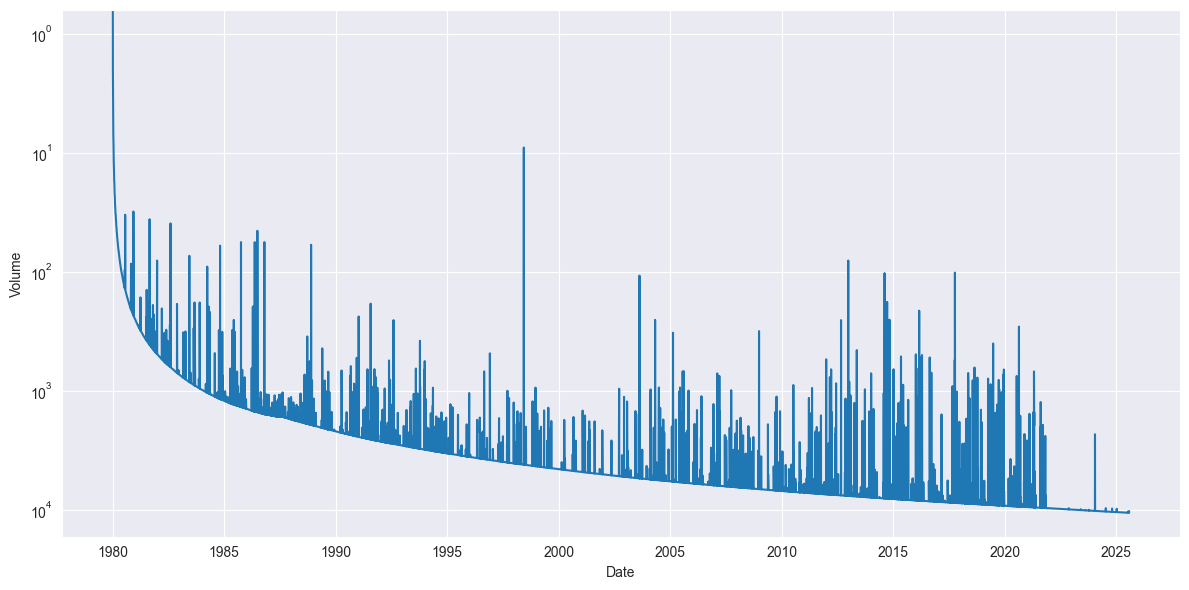

In [ ]:
sns.lineplot(data=df, x='Date', y='Volume')

plt.yscale('log')
plt.tight_layout()
plt.show()

## Dividends and stock splits

In [56]:
df[df["Dividends"] > 0].shape[0]

182

In [57]:
df[df["Stock Splits"] > 0]

,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Adj Factor,days_gap
4400,1997-05-28,43.260036,43.917305,42.304016,43.080784,5.275114,"18,722,145",0.0,2.00,0.122447,1.0
4904,1999-05-27,111.555923,111.735184,107.672081,110.898659,27.524728,"11,037,915",0.0,2.00,0.248197,1.0
10552,2021-11-04,123.050003,123.339996,119.900002,120.849998,98.262825,"7,208,700",0.0,1.05,0.813097,1.0


## Correlation

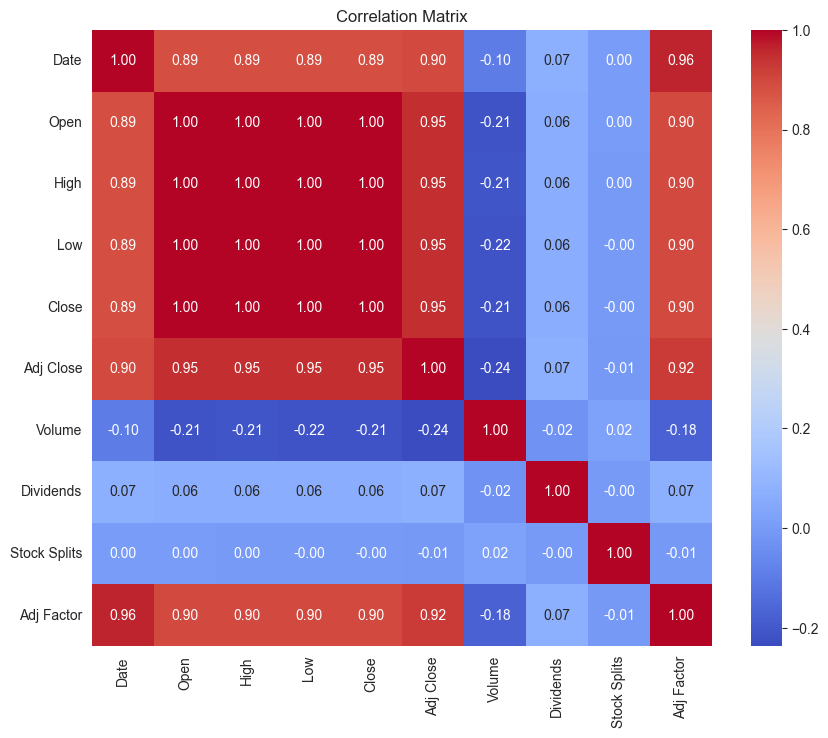

In [17]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Outliers
Using boxplots and IQR to check for outliers in price and volume.

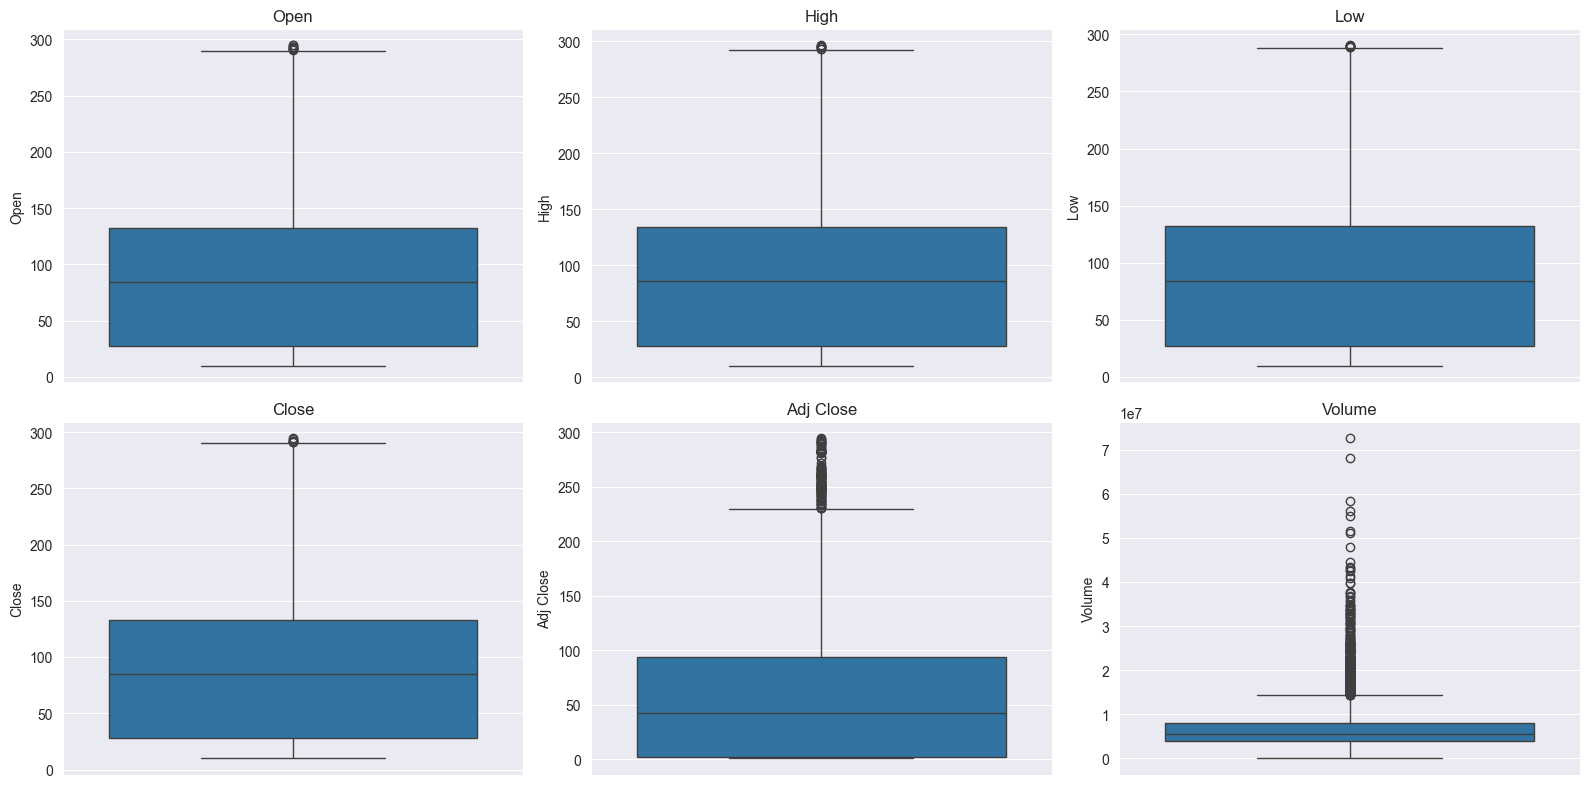

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
cols_to_plot = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]

for ax, col in zip(axes.flatten(), cols_to_plot):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
for col in cols_to_plot:
    print(col, "outliers:", count_outliers_iqr(df[col]))

Open outliers: 9
High outliers: 8
Low outliers: 8
Close outliers: 7
Adj Close outliers: 124
Volume outliers: 560


## Daily returns
Helps see volatility and spot extreme days.

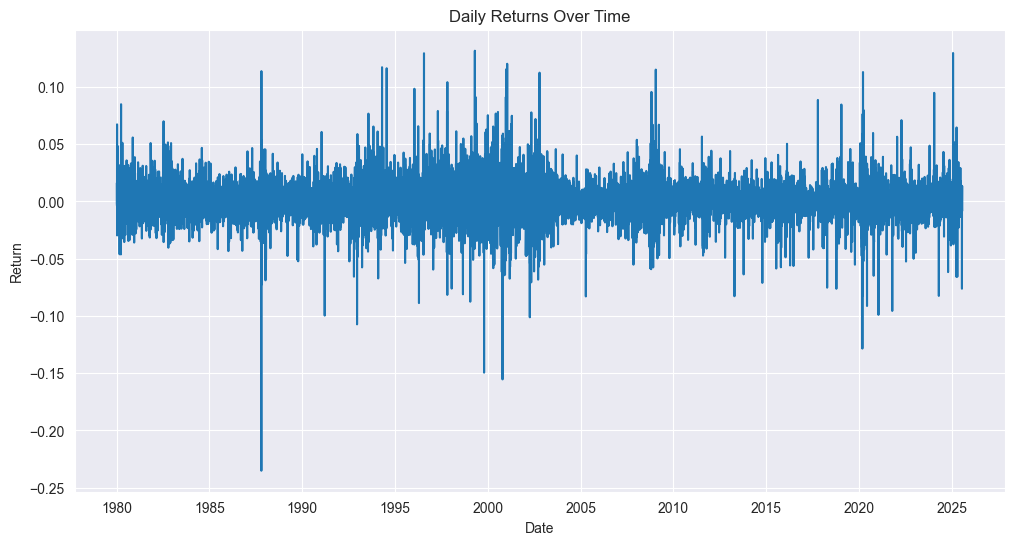

In [24]:
df["daily_return"] = df["Close"].pct_change()

plt.plot(df["Date"], df["daily_return"])
plt.title("Daily Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

In [28]:
df[df['daily_return'] < -0.2]

,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Adj Factor,daily_return,adj_daily_return
1971,1987-10-19,32.265774,32.982792,23.900574,24.677341,2.200134,26670490.0,0.0,0.0,0.089156,-0.235185,-0.235185


In [31]:
df["daily_return"].describe()

count    11487.000000
mean         0.000390
std          0.016760
min         -0.235185
25%         -0.007955
50%          0.000052
75%          0.008511
max          0.131636
Name: daily_return, dtype: float64

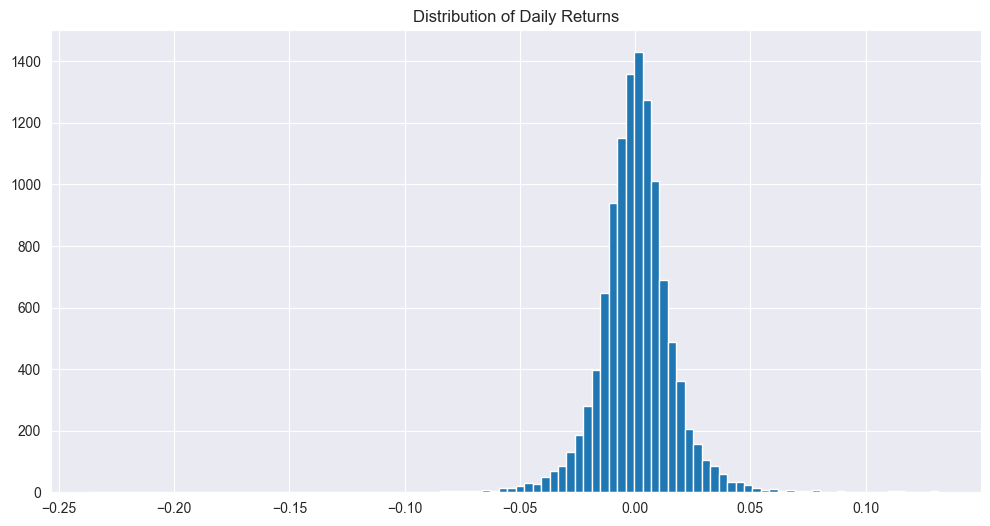

In [32]:
plt.hist(df["daily_return"].dropna(), bins=100)
plt.title("Distribution of Daily Returns")
plt.show()

In [33]:
# biggest single day drops and gains
df.nsmallest(5, "daily_return")[["Date", "daily_return"]]

,Date,daily_return
1971,1987-10-19,-0.235185
5257,2000-10-18,-0.155420
5006,1999-10-21,-0.149533
10135,2020-03-12,-0.128507
3276,1992-12-15,-0.107356


In [34]:
df.nlargest(5, "daily_return")[["Date", "daily_return"]]

,Date,daily_return
4879,1999-04-22,0.131636
11363,2025-01-30,0.129642
4188,1996-07-25,0.129428
5319,2001-01-18,0.120233
3617,1994-04-21,0.117225


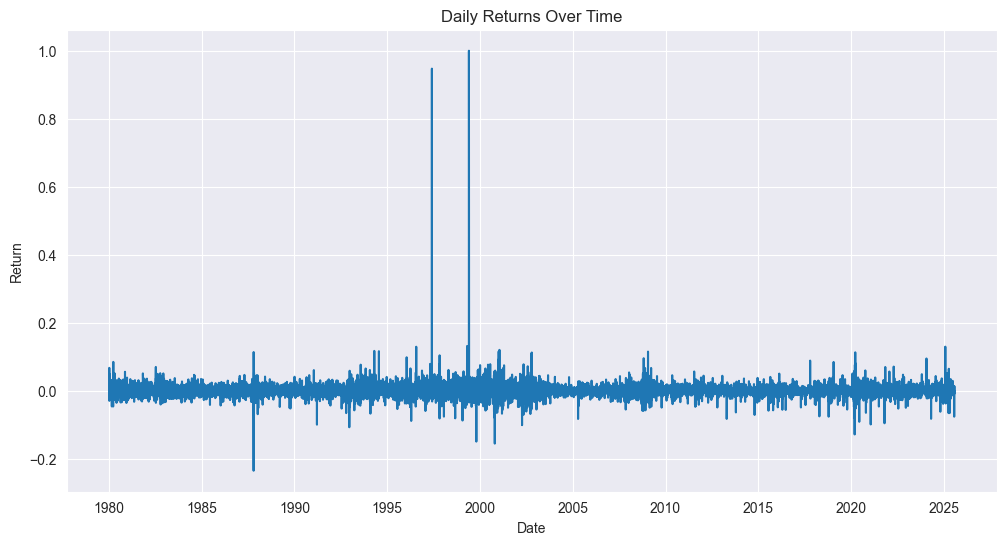

In [26]:
df["adj_daily_return"] = df["Adj Close"].pct_change()

plt.plot(df["Date"], df["adj_daily_return"])
plt.title("Daily Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

In [30]:
df[df["adj_daily_return"] > 0.2]

,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Adj Factor,daily_return,adj_daily_return
4401,1997-05-29,43.021034,43.021034,41.826004,41.945507,10.272206,12079626.0,0.0,0.0,0.244894,-0.026352,0.947295
4905,1999-05-28,110.898659,111.615677,109.165871,110.898659,55.049457,6672957.0,0.0,0.0,0.496394,0.000000,1.000000


In [ ]:
df["adj_daily_return"].describe()

count    11487.000000
mean         0.000680
std          0.021145
min         -0.235185
25%         -0.007899
50%          0.000246
75%          0.008651
max          1.000000
Name: daily_return, dtype: float64

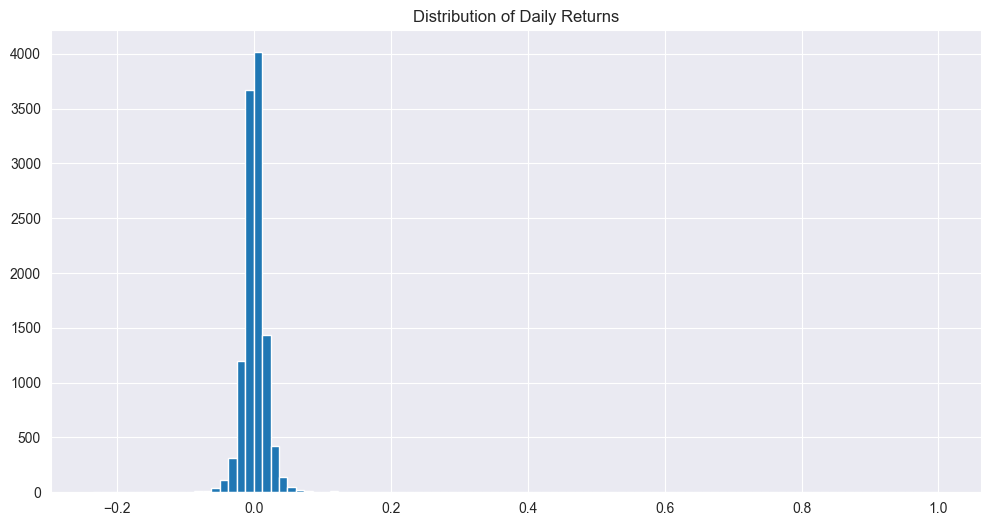

In [ ]:
plt.hist(df["adj_daily_return"].dropna(), bins=100)
plt.title("Distribution of Daily Returns")
plt.show()

In [ ]:
# biggest single day drops and gains
df.nsmallest(5, "adj_daily_return")[["Date", "adj_daily_return"]]

,Date,daily_return
1971,1987-10-19,-0.235185
5257,2000-10-18,-0.155420
5006,1999-10-21,-0.149533
10135,2020-03-12,-0.128507
3276,1992-12-15,-0.107356


In [ ]:
df.nlargest(5, "adj_daily_return")[["Date", "adj_daily_return"]]

,Date,daily_return
4905,1999-05-28,1.000000
4401,1997-05-29,0.947295
4879,1999-04-22,0.131636
11363,2025-01-30,0.129642
4188,1996-07-25,0.129428


## Yearly summary

In [35]:
df["year"] = df["Date"].dt.year
close_yearly = df.groupby("year")["Close"].agg(["mean", "min", "max"])
close_yearly.tail(15)

,mean,min,max
year,,,
2011,163.407539,140.583176,186.003830
2012,187.945469,171.281067,201.720840
2013,185.610679,165.200760,206.309753
2014,174.286928,144.751434,189.072662
2015,148.520023,125.956024,166.730408
2016,143.895717,112.667305,161.099426
2017,150.724673,133.556412,173.948380
2018,137.529233,102.839386,161.682602
2019,130.964218,107.944550,144.703629


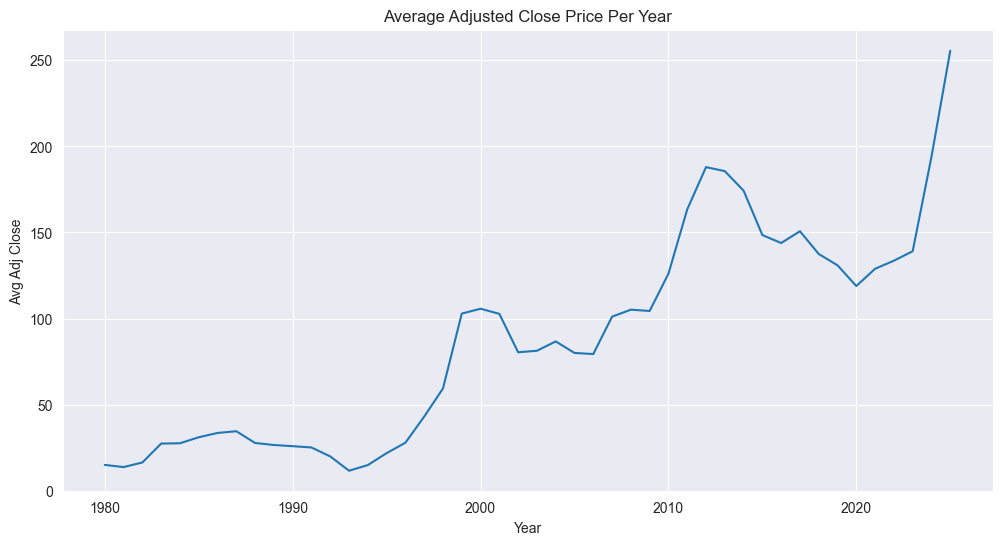

In [36]:
plt.plot(close_yearly.index, close_yearly["mean"])
plt.title("Average Adjusted Close Price Per Year")
plt.xlabel("Year")
plt.ylabel("Avg Adj Close")
plt.show()

In [37]:
df["year"] = df["Date"].dt.year
adj_close_yearly = df.groupby("year")["Adj Close"].agg(["mean", "min", "max"])
adj_close_yearly.tail(15)

,mean,min,max
year,,,
2011,92.989087,79.276778,106.678720
2012,108.719109,98.234778,117.136669
2013,109.286158,97.744710,120.847468
2014,104.874966,88.167136,113.041069
2015,91.893491,79.254620,102.853265
2016,92.472666,71.626331,105.249784
2017,100.318113,89.772519,114.554637
2018,95.382553,73.035784,109.773625
2019,95.356806,76.661434,105.253168


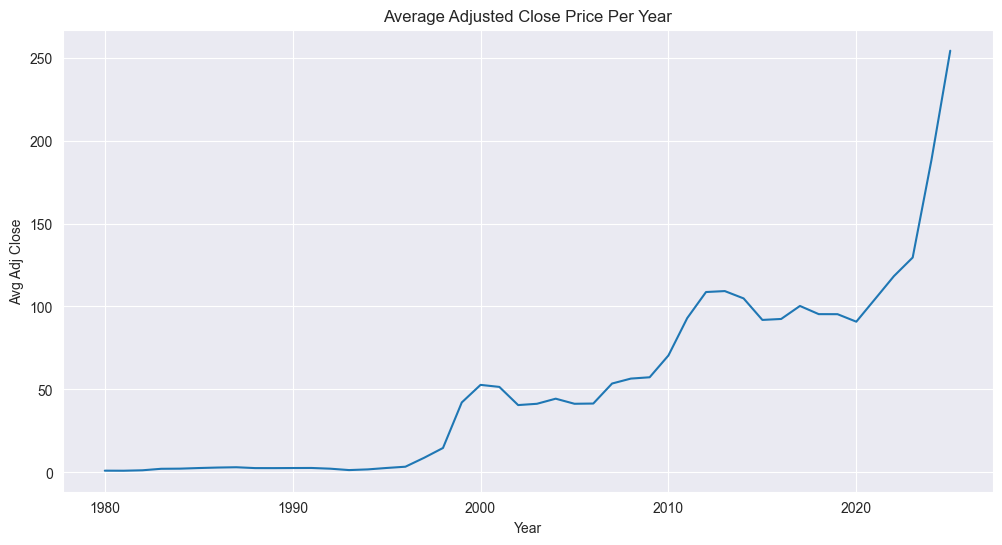

In [38]:
plt.plot(adj_close_yearly.index, adj_close_yearly["mean"])
plt.title("Average Adjusted Close Price Per Year")
plt.xlabel("Year")
plt.ylabel("Avg Adj Close")
plt.show()